# 🇮🇳 India News Headlines — Complete NLP & ML Pipeline
## Part 1: Traditional ML + Deep Learning Models

**Dataset:** India News Headlines (Kaggle) — ~1M rows, 3 columns: `publish_date`, `headline_category`, `headline_text`

**Task:** Binary classification — *Credible* (known editorial category) vs *Suspect* (category = `unknown` / `removed`)

**Models:** 10 Traditional ML + 7 Deep Learning = **17 models total**

**Metrics:** Accuracy, Precision, Recall, F1-Score, ROC-AUC, RMSE, MSE, MAE, R², MAPE

**Visualisations:** Confusion matrices, ROC curves, Heatmaps, Radar chart, Training curves

---
*Note: The dataset has no ground-truth real/fake labels. `headline_category` is used as a proxy — headlines categorised as `unknown` or `removed` are treated as the **suspect class**, which mirrors real-world fake-news framing where unverified/deleted content is flagged.*

## 1. Install Dependencies

In [7]:
# Run once — comment out after first run
!pip install scikit-learn xgboost lightgbm gensim tensorflow keras matplotlib seaborn pandas numpy

## 2. Imports & Configuration

In [2]:
import warnings, os, gc, json, pickle
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                               GradientBoostingClassifier, AdaBoostClassifier)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve,
    mean_squared_error, mean_absolute_error, r2_score
)
import xgboost as xgb
import lightgbm as lgb

# ── Gensim ────────────────────────────────────────────────────────────────────
from gensim.models import Word2Vec

# ── TensorFlow / Keras ────────────────────────────────────────────────────────
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
from tensorflow.keras import layers as L, Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print(f"TensorFlow  : {tf.__version__}")
print(f"Scikit-learn: {__import__('sklearn').__version__}")
print(f"XGBoost     : {xgb.__version__}")
print(f"LightGBM    : {lgb.__version__}")

TensorFlow  : 2.19.0
Scikit-learn: 1.6.1
XGBoost     : 3.2.0
LightGBM    : 4.6.0


## 3. Helper Functions

In [3]:
# ── MAPE ──────────────────────────────────────────────────────────────────────
def mape(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.clip(np.array(y_pred, dtype=float), 1e-9, None)
    mask = y_true != 0
    return float(np.mean(np.abs((y_true[mask]-y_pred[mask])/y_true[mask]))*100) if mask.sum()>0 else float('nan')

# ── All metrics ───────────────────────────────────────────────────────────────
def compute_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy' : float(accuracy_score(y_true, y_pred)),
        'Precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'Recall'   : float(recall_score(y_true, y_pred, zero_division=0)),
        'F1-Score' : float(f1_score(y_true, y_pred, zero_division=0)),
        'ROC-AUC'  : float(roc_auc_score(y_true, y_prob)),
        'RMSE'     : float(np.sqrt(mean_squared_error(y_true, y_prob))),
        'MSE'      : float(mean_squared_error(y_true, y_prob)),
        'MAE'      : float(mean_absolute_error(y_true, y_prob)),
        'R²'       : float(r2_score(y_true, y_prob)),
        'MAPE (%)'  : mape(y_true, y_prob)
    }

# ── Sequence padding (NumPy — no keras_preprocessing needed) ──────────────────
def pad_sequences_np(sequences, maxlen, value=0):
    out = np.full((len(sequences), maxlen), value, dtype='int32')
    for i, seq in enumerate(sequences):
        seq = list(seq)[:maxlen]
        out[i, :len(seq)] = seq
    return out

# ── Build vocabulary from training texts ─────────────────────────────────────
def build_vocab(texts, num_words=20_000):
    from collections import Counter
    counts = Counter(w for t in texts for w in t.lower().split())
    vocab  = {w: i+2 for i, (w, _) in enumerate(counts.most_common(num_words-2))}
    return vocab  # 0=PAD, 1=OOV

def encode_texts(texts, vocab):
    return [[vocab.get(w, 1) for w in t.lower().split()] for t in texts]

# ── tf.data helpers ───────────────────────────────────────────────────────────
def make_dataset(X, y, sample_weights=None, batch_size=1024, shuffle=False):
    X_t = tf.constant(X)
    y_t = tf.constant(y, dtype=tf.float32)
    if sample_weights is not None:
        sw_t = tf.constant(sample_weights, dtype=tf.float32)
        ds = tf.data.Dataset.from_tensor_slices((X_t, y_t, sw_t))
    else:
        ds = tf.data.Dataset.from_tensor_slices((X_t, y_t))
    if shuffle:
        ds = ds.shuffle(buffer_size=10_000, seed=42)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# ── Word2Vec average embedding ────────────────────────────────────────────────
def avg_word2vec(texts, model, dim=100):
    vecs = []
    for text in texts:
        words = [w for w in text.lower().split() if w in model.wv]
        vecs.append(np.mean([model.wv[w] for w in words], axis=0) if words else np.zeros(dim))
    return np.array(vecs, dtype='float32')

print("Helper functions defined ✓")

Helper functions defined ✓


## 4. Load & Prepare Data

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
'''Adjust path to the local CSV file (unzip the Kaggle download first)'''
'Dataset: https://www.kaggle.com/datasets/therohk/india-headlines-news-dataset'
# ─────────────────────────────────────────────────────────────────────────────
DATA_PATH  = '/content/india-news-headlines.csv'   
SAMPLE_SIZE = 200_000                      #increase up to 1M if RAM allows
RANDOM_STATE = 42

df = pd.read_csv(DATA_PATH, nrows=SAMPLE_SIZE, dtype=str)
df = df.dropna(subset=['headline_category', 'headline_text'])
df['headline_text'] = df['headline_text'].str.strip()
df = df[df['headline_text'].str.len() > 5].reset_index(drop=True)

# ── Binary labelling ──────────────────────────────────────────────────────────
# Suspect = category 'unknown' or 'removed'  →  1
# Credible = any proper editorial category   →  0
SUSPECT_CATS = {'unknown', 'removed'}
df['label'] = df['headline_category'].apply(
    lambda c: 1 if str(c).lower() in SUSPECT_CATS else 0
)

vc = df['label'].value_counts()
print(f"Dataset size  : {len(df):,}")
print(f"Credible  (0) : {vc[0]:,}  ({vc[0]/len(df)*100:.1f}%)")
print(f"Suspect   (1) : {vc[1]:,}  ({vc[1]/len(df)*100:.1f}%)")
print(f"Class ratio   : {vc[0]/vc[1]:.2f} : 1")
print()
print(df[['publish_date','headline_category','headline_text','label']].head(5).to_string())

Dataset size  : 200,000
Credible  (0) : 164,567  (82.3%)
Suspect   (1) : 35,433  (17.7%)
Class ratio   : 4.64 : 1

  publish_date headline_category                                               headline_text  label
0     20010102           unknown  Status quo will not be disturbed at Ayodhya; says Vajpayee      1
1     20010102           unknown                         Fissures in Hurriyat over Pak visit      1
2     20010102           unknown                       America's unwanted heading for India?      1
3     20010102           unknown                          For bigwigs; it is destination Goa      1
4     20010102           unknown                        Extra buses to clear tourist traffic      1


## 5. Exploratory Data Analysis

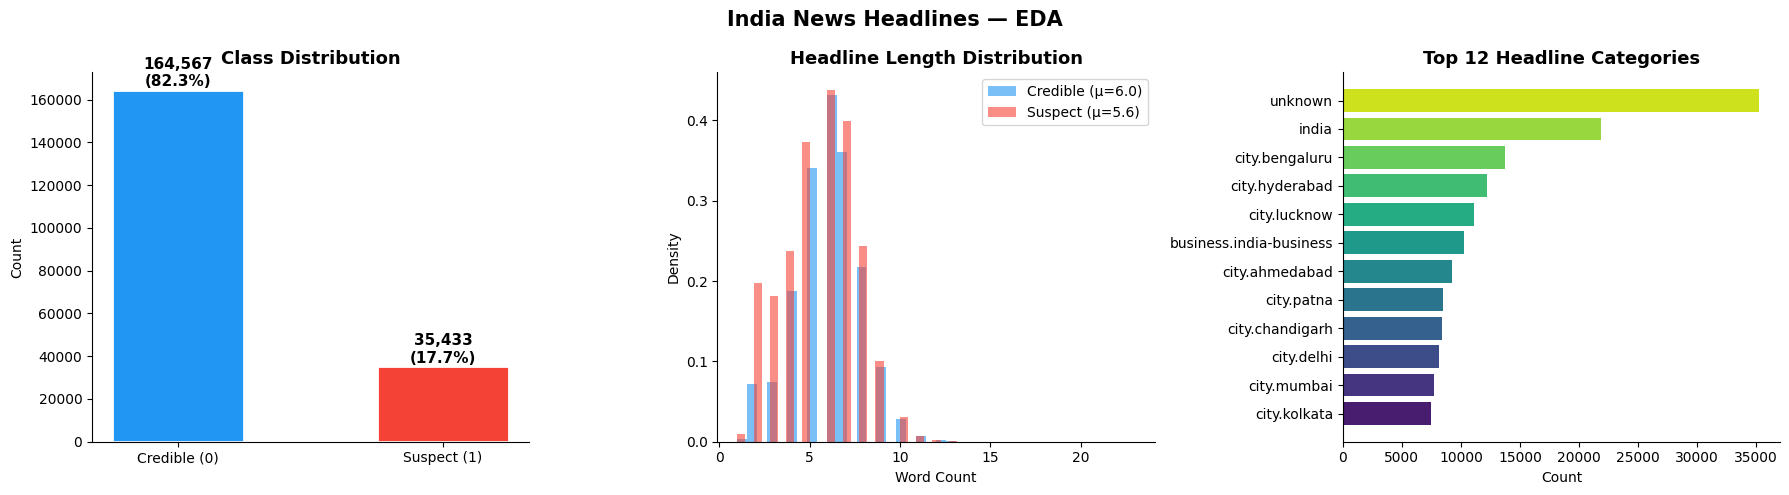


Avg headline length (Credible): 6.0 words
Avg headline length (Suspect) : 5.6 words


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Class distribution
ax = axes[0]
bars = ax.bar(['Credible (0)', 'Suspect (1)'], [vc[0], vc[1]],
               color=['#2196F3', '#F44336'], edgecolor='white', linewidth=2, width=0.5)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+200,
            f'{b.get_height():,}\n({b.get_height()/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Class Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Count'); sns.despine(ax=ax)

# Headline length distribution
ax = axes[1]
df['text_len'] = df['headline_text'].str.split().str.len()
for label, color, name in [(0,'#2196F3','Credible'),(1,'#F44336','Suspect')]:
    subset = df[df['label']==label]['text_len']
    ax.hist(subset, bins=40, alpha=0.6, color=color, label=f'{name} (μ={subset.mean():.1f})', density=True)
ax.set_title('Headline Length Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Word Count'); ax.set_ylabel('Density'); ax.legend(); sns.despine(ax=ax)

# Top categories
ax = axes[2]
top_cats = df['headline_category'].value_counts().head(12)
ax.barh(top_cats.index[::-1], top_cats.values[::-1], color=sns.color_palette('viridis',12))
ax.set_title('Top 12 Headline Categories', fontsize=13, fontweight='bold')
ax.set_xlabel('Count'); sns.despine(ax=ax)

plt.suptitle('India News Headlines — EDA', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"\nAvg headline length (Credible): {df[df.label==0].text_len.mean():.1f} words")
print(f"Avg headline length (Suspect) : {df[df.label==1].text_len.mean():.1f} words")

## 6. Train/Test Split & Feature Engineering

In [6]:
X_raw = df['headline_text'].values
y     = df['label'].values

X_tr_raw, X_te_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {len(X_tr_raw):,}  |  Test: {len(X_te_raw):,}")

# ── TF-IDF (for traditional ML) ───────────────────────────────────────────────
print("\nFitting TF-IDF vectoriser...")
tfidf = TfidfVectorizer(
    max_features  = 40_000,
    ngram_range   = (1, 2),
    sublinear_tf  = True,
    min_df        = 3,
    strip_accents = 'unicode'
)
X_tr_tfidf = tfidf.fit_transform(X_tr_raw)
X_te_tfidf = tfidf.transform(X_te_raw)
print(f"TF-IDF matrix: {X_tr_tfidf.shape}")

# ── Sequence encoding (for deep learning) ─────────────────────────────────────
MAX_WORDS = 30_000
MAX_LEN   = 30
EMBED_DIM = 64
POS_WEIGHT = float(vc[0] / vc[1])   # class imbalance weight

print("\nBuilding vocabulary & sequences...")
vocab     = build_vocab(X_tr_raw, MAX_WORDS)
X_tr_seq  = pad_sequences_np(encode_texts(X_tr_raw, vocab), MAX_LEN)
X_te_seq  = pad_sequences_np(encode_texts(X_te_raw, vocab), MAX_LEN)
print(f"Sequence matrix: {X_tr_seq.shape}")

# ── Word2Vec embeddings (for MLP) ─────────────────────────────────────────────
print("\nTraining Word2Vec (this may take ~1 min)...")
w2v_model = Word2Vec(
    [t.lower().split() for t in X_tr_raw],
    vector_size=100, window=5, min_count=3, workers=4, epochs=5, seed=42
)
X_tr_w2v = avg_word2vec(X_tr_raw, w2v_model)
X_te_w2v  = avg_word2vec(X_te_raw,  w2v_model)
print(f"Word2Vec matrix: {X_tr_w2v.shape}")

y_train_f = y_train.astype('float32')
y_test_f  = y_test.astype('float32')
print("\nFeature engineering complete ✓")

Train: 160,000  |  Test: 40,000

Fitting TF-IDF vectoriser...
TF-IDF matrix: (160000, 40000)

Building vocabulary & sequences...
Sequence matrix: (160000, 30)

Training Word2Vec (this may take ~1 min)...
Word2Vec matrix: (160000, 100)

Feature engineering complete ✓


## 7. Traditional ML Models (10 Models)

In [8]:
# ── Model definitions ────────────────────────────────────────────────────────
CW = {'class_weight': 'balanced'}

ML_MODELS = {
    'Logistic Regression' : LogisticRegression(max_iter=500, C=1.0, solver='lbfgs', n_jobs=-1, **CW),
    'Naive Bayes'         : MultinomialNB(alpha=0.1),
    'SVM (LinearSVC)'     : CalibratedClassifierCV(LinearSVC(max_iter=2000, C=1.0, class_weight='balanced'), cv=3),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, max_depth=20, n_jobs=-1, random_state=42, **CW),
    'Extra Trees'         : ExtraTreesClassifier(n_estimators=200, max_depth=20, n_jobs=-1, random_state=42, **CW),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42),
    'XGBoost'             : xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                               scale_pos_weight=POS_WEIGHT, eval_metric='logloss',
                                               n_jobs=-1, random_state=42),
    'LightGBM'            : lgb.LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                                is_unbalance=True, n_jobs=-1, random_state=42, verbose=-1),
    'AdaBoost'            : AdaBoostClassifier(n_estimators=100, learning_rate=0.5, random_state=42),
    'Ridge Classifier'    : CalibratedClassifierCV(RidgeClassifier(alpha=1.0, class_weight='balanced'), cv=3),
}

# ── Train & evaluate ─────────────────────────────────────────────────────────
ML_RESULTS = {}
ML_ROC     = {}
ML_CM      = {}

print(f"{'Model':<25} {'AUC':>7} {'F1':>7} {'Acc':>7} {'Prec':>7} {'Rec':>7}")
print("-"*60)
for name, model in ML_MODELS.items():
    model.fit(X_tr_tfidf, y_train)
    y_pred = model.predict(X_te_tfidf)
    y_prob = model.predict_proba(X_te_tfidf)[:, 1]
    m = compute_metrics(y_test, y_pred, y_prob)
    ML_RESULTS[name] = m
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ML_ROC[name] = (fpr, tpr)
    ML_CM[name]  = confusion_matrix(y_test, y_pred)
    print(f"{name:<25} {m['ROC-AUC']:>7.4f} {m['F1-Score']:>7.4f} {m['Accuracy']:>7.4f} {m['Precision']:>7.4f} {m['Recall']:>7.4f}")
    gc.collect()

print("\n✓ All traditional ML models trained.")

Model                         AUC      F1     Acc    Prec     Rec
------------------------------------------------------------
Logistic Regression        0.7653  0.4615  0.7502  0.3734  0.6039
Naive Bayes                0.7558  0.3253  0.8432  0.6845  0.2133
SVM (LinearSVC)            0.7521  0.2136  0.8388  0.7864  0.1236
Random Forest              0.7177  0.4013  0.7706  0.3733  0.4338
Extra Trees                0.7300  0.4084  0.8011  0.4316  0.3876
Gradient Boosting          0.6616  0.1505  0.8344  0.8233  0.0828
XGBoost                    0.7089  0.3920  0.6356  0.2783  0.6629
LightGBM                   0.7054  0.3924  0.6489  0.2830  0.6399
AdaBoost                   0.5420  0.0003  0.8228  1.0000  0.0001
Ridge Classifier           0.7561  0.2269  0.8387  0.7522  0.1336

✓ All traditional ML models trained.


## 8. Deep Learning Models (7 Models)

In [9]:
# ── Shared training config ────────────────────────────────────────────────────
EPOCHS   = 15
BATCH    = 512
CB_LIST  = [
    EarlyStopping(patience=3, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(patience=2, factor=0.5, monitor='val_loss', verbose=0)
]

DL_RESULTS = {}
DL_ROC     = {}
DL_CM      = {}
DL_HISTORY = {}

def run_dl_model(name, model, X_tr, X_te, y_tr, y_te, epochs=EPOCHS):
    """Compile, train, and evaluate a Keras DL model using tf.data pipelines."""
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    # Compute sample weights for class balance
    sw = np.where(y_tr == 1, POS_WEIGHT, 1.0).astype('float32')
    # Manual train/val split (10%)
    n_val = int(len(X_tr) * 0.1)
    Xtr_fit, Xvl_fit = X_tr[:-n_val], X_tr[-n_val:]
    ytr_fit, yvl_fit = y_tr[:-n_val], y_tr[-n_val:]
    sw_fit            = sw[:-n_val]

    tr_ds  = make_dataset(Xtr_fit, ytr_fit, sw_fit, batch_size=BATCH, shuffle=True)
    val_ds = make_dataset(Xvl_fit, yvl_fit, batch_size=BATCH)

    hist = model.fit(tr_ds, validation_data=val_ds,
                     epochs=epochs, callbacks=CB_LIST, verbose=0)

    te_ds  = make_dataset(X_te, y_te, batch_size=BATCH)
    y_prob = model.predict(te_ds, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    m = compute_metrics(y_te, y_pred, y_prob)
    DL_RESULTS[name] = m
    fpr, tpr, _  = roc_curve(y_te, y_prob)
    DL_ROC[name]     = (fpr, tpr)
    DL_CM[name]      = confusion_matrix(y_te, y_pred)
    DL_HISTORY[name] = hist.history
    print(f"  {name:<28} AUC={m['ROC-AUC']:.4f}  F1={m['F1-Score']:.4f}  Acc={m['Accuracy']:.4f}")
    tf.keras.backend.clear_session(); gc.collect()
    return hist

print("Training Deep Learning models (CPU may take 10-30 min; GPU ~2-5 min)...")
print("-"*65)

# ── Model 1: TextCNN ─────────────────────────────────────────────────────────
inp  = L.Input(shape=(MAX_LEN,))
emb  = L.Embedding(MAX_WORDS, EMBED_DIM)(inp)
sd   = L.SpatialDropout1D(0.3)(emb)
pools = [L.GlobalMaxPooling1D()(L.Conv1D(128, k, activation='relu')(sd)) for k in [2, 3, 4]]
cat  = L.Concatenate()(pools)
out  = L.Dense(1, activation='sigmoid')(L.Dropout(0.3)(L.Dense(64, activation='relu')(cat)))
run_dl_model('TextCNN', Model(inp, out), X_tr_seq, X_te_seq, y_train_f, y_test_f)

# ── Model 2: LSTM ─────────────────────────────────────────────────────────────
run_dl_model('LSTM', Sequential([
    L.Embedding(MAX_WORDS, EMBED_DIM),
    L.SpatialDropout1D(0.3),
    L.LSTM(128, dropout=0.3, recurrent_dropout=0.2),
    L.Dense(64, activation='relu'), L.Dropout(0.3),
    L.Dense(1, activation='sigmoid')
]), X_tr_seq, X_te_seq, y_train_f, y_test_f)

# ── Model 3: Bidirectional LSTM ───────────────────────────────────────────────
run_dl_model('Bidirectional LSTM', Sequential([
    L.Embedding(MAX_WORDS, EMBED_DIM),
    L.SpatialDropout1D(0.3),
    L.Bidirectional(L.LSTM(128, dropout=0.3, recurrent_dropout=0.2)),
    L.Dense(64, activation='relu'), L.Dropout(0.3),
    L.Dense(1, activation='sigmoid')
]), X_tr_seq, X_te_seq, y_train_f, y_test_f)

# ── Model 4: GRU ──────────────────────────────────────────────────────────────
run_dl_model('GRU', Sequential([
    L.Embedding(MAX_WORDS, EMBED_DIM),
    L.SpatialDropout1D(0.3),
    L.GRU(128, dropout=0.3, recurrent_dropout=0.2),
    L.Dense(64, activation='relu'), L.Dropout(0.3),
    L.Dense(1, activation='sigmoid')
]), X_tr_seq, X_te_seq, y_train_f, y_test_f)

# ── Model 5: Bidirectional GRU ────────────────────────────────────────────────
run_dl_model('Bidirectional GRU', Sequential([
    L.Embedding(MAX_WORDS, EMBED_DIM),
    L.SpatialDropout1D(0.3),
    L.Bidirectional(L.GRU(128, dropout=0.3, recurrent_dropout=0.2)),
    L.Dense(64, activation='relu'), L.Dropout(0.3),
    L.Dense(1, activation='sigmoid')
]), X_tr_seq, X_te_seq, y_train_f, y_test_f)

# ── Model 6: CNN-LSTM Hybrid ──────────────────────────────────────────────────
run_dl_model('CNN-LSTM Hybrid', Sequential([
    L.Embedding(MAX_WORDS, EMBED_DIM),
    L.SpatialDropout1D(0.3),
    L.Conv1D(64, 3, activation='relu'), L.Dropout(0.2),
    L.LSTM(64, dropout=0.3),
    L.Dense(64, activation='relu'), L.Dropout(0.3),
    L.Dense(1, activation='sigmoid')
]), X_tr_seq, X_te_seq, y_train_f, y_test_f)

# ── Model 7: Deep MLP on Word2Vec ─────────────────────────────────────────────
run_dl_model('Deep MLP (Word2Vec)', Sequential([
    L.Dense(512, activation='relu', input_shape=(100,)),
    L.BatchNormalization(), L.Dropout(0.5),
    L.Dense(256, activation='relu'), L.BatchNormalization(), L.Dropout(0.4),
    L.Dense(128, activation='relu'), L.Dropout(0.3),
    L.Dense(1, activation='sigmoid')
]), X_tr_w2v, X_te_w2v, y_train_f, y_test_f)

print("\n✓ All deep learning models trained.")

Training Deep Learning models (CPU may take 10-30 min; GPU ~2-5 min)...
-----------------------------------------------------------------
  TextCNN                      AUC=0.7525  F1=0.4539  Acc=0.7494
  LSTM                         AUC=0.6621  F1=0.3480  Acc=0.4568
  Bidirectional LSTM           AUC=0.7712  F1=0.4723  Acc=0.7809
  GRU                          AUC=0.5007  F1=0.3010  Acc=0.1772
  Bidirectional GRU            AUC=0.7639  F1=0.4622  Acc=0.7619
  CNN-LSTM Hybrid              AUC=0.5917  F1=0.0000  Acc=0.8228
  Deep MLP (Word2Vec)          AUC=0.6415  F1=0.3429  Acc=0.6886

✓ All deep learning models trained.


## 9. Unified Metrics Table (All 17 Models)

In [10]:
ALL_RESULTS = {**ML_RESULTS, **DL_RESULTS}
ALL_ROC     = {**ML_ROC,     **DL_ROC}
ALL_CM      = {**ML_CM,      **DL_CM}
MODEL_NAMES = list(ALL_RESULTS.keys())
ML_NAMES    = list(ML_RESULTS.keys())
DL_NAMES    = list(DL_RESULTS.keys())

metrics_df = pd.DataFrame(ALL_RESULTS).T
metrics_df = metrics_df[['Accuracy','Precision','Recall','F1-Score','ROC-AUC',
                           'RMSE','MSE','MAE','R²','MAPE (%)']]
metrics_df = metrics_df.astype(float)
metrics_df.to_csv('metrics_all_models.csv')
print(metrics_df.round(4).to_string())

print("\n── Best Model per Metric ──────────────────────────────────────────────")
for col in ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']:
    best = metrics_df[col].idxmax()
    print(f"  Best {col:<14}: {best:<30}  ({metrics_df.loc[best,col]:.4f})")
for col in ['RMSE','MSE','MAE','MAPE (%)']:
    best = metrics_df[col].idxmin()
    print(f"  Best {col:<14}: {best:<30}  ({metrics_df.loc[best,col]:.4f})")

                     Accuracy  Precision  Recall  F1-Score  ROC-AUC    RMSE     MSE     MAE      R²  MAPE (%)
Logistic Regression    0.7502     0.3734  0.6039    0.4615   0.7653  0.4173  0.1742  0.3682 -0.1946   42.3580
Naive Bayes            0.8432     0.6845  0.2133    0.3253   0.7558  0.3484  0.1214  0.2277  0.1672   68.1030
SVM (LinearSVC)        0.8388     0.7864  0.1236    0.2136   0.7521  0.3507  0.1230  0.2536  0.1564   71.5470
Random Forest          0.7706     0.3733  0.4338    0.4013   0.7177  0.4923  0.2423  0.4920 -0.6623   49.4436
Extra Trees            0.8010     0.4316  0.3876    0.4084   0.7300  0.4951  0.2451  0.4950 -0.6812   49.5779
Gradient Boosting      0.8344     0.8233  0.0828    0.1505   0.6616  0.3652  0.1334  0.2740  0.0851   77.2805
XGBoost                0.6356     0.2783  0.6629    0.3920   0.7089  0.4633  0.2147  0.4525 -0.4727   45.7603
LightGBM               0.6489     0.2830  0.6399    0.3924   0.7054  0.4643  0.2155  0.4537 -0.4785   45.8304
AdaBoost  

## 10. Confusion Matrices (All 17 Models)

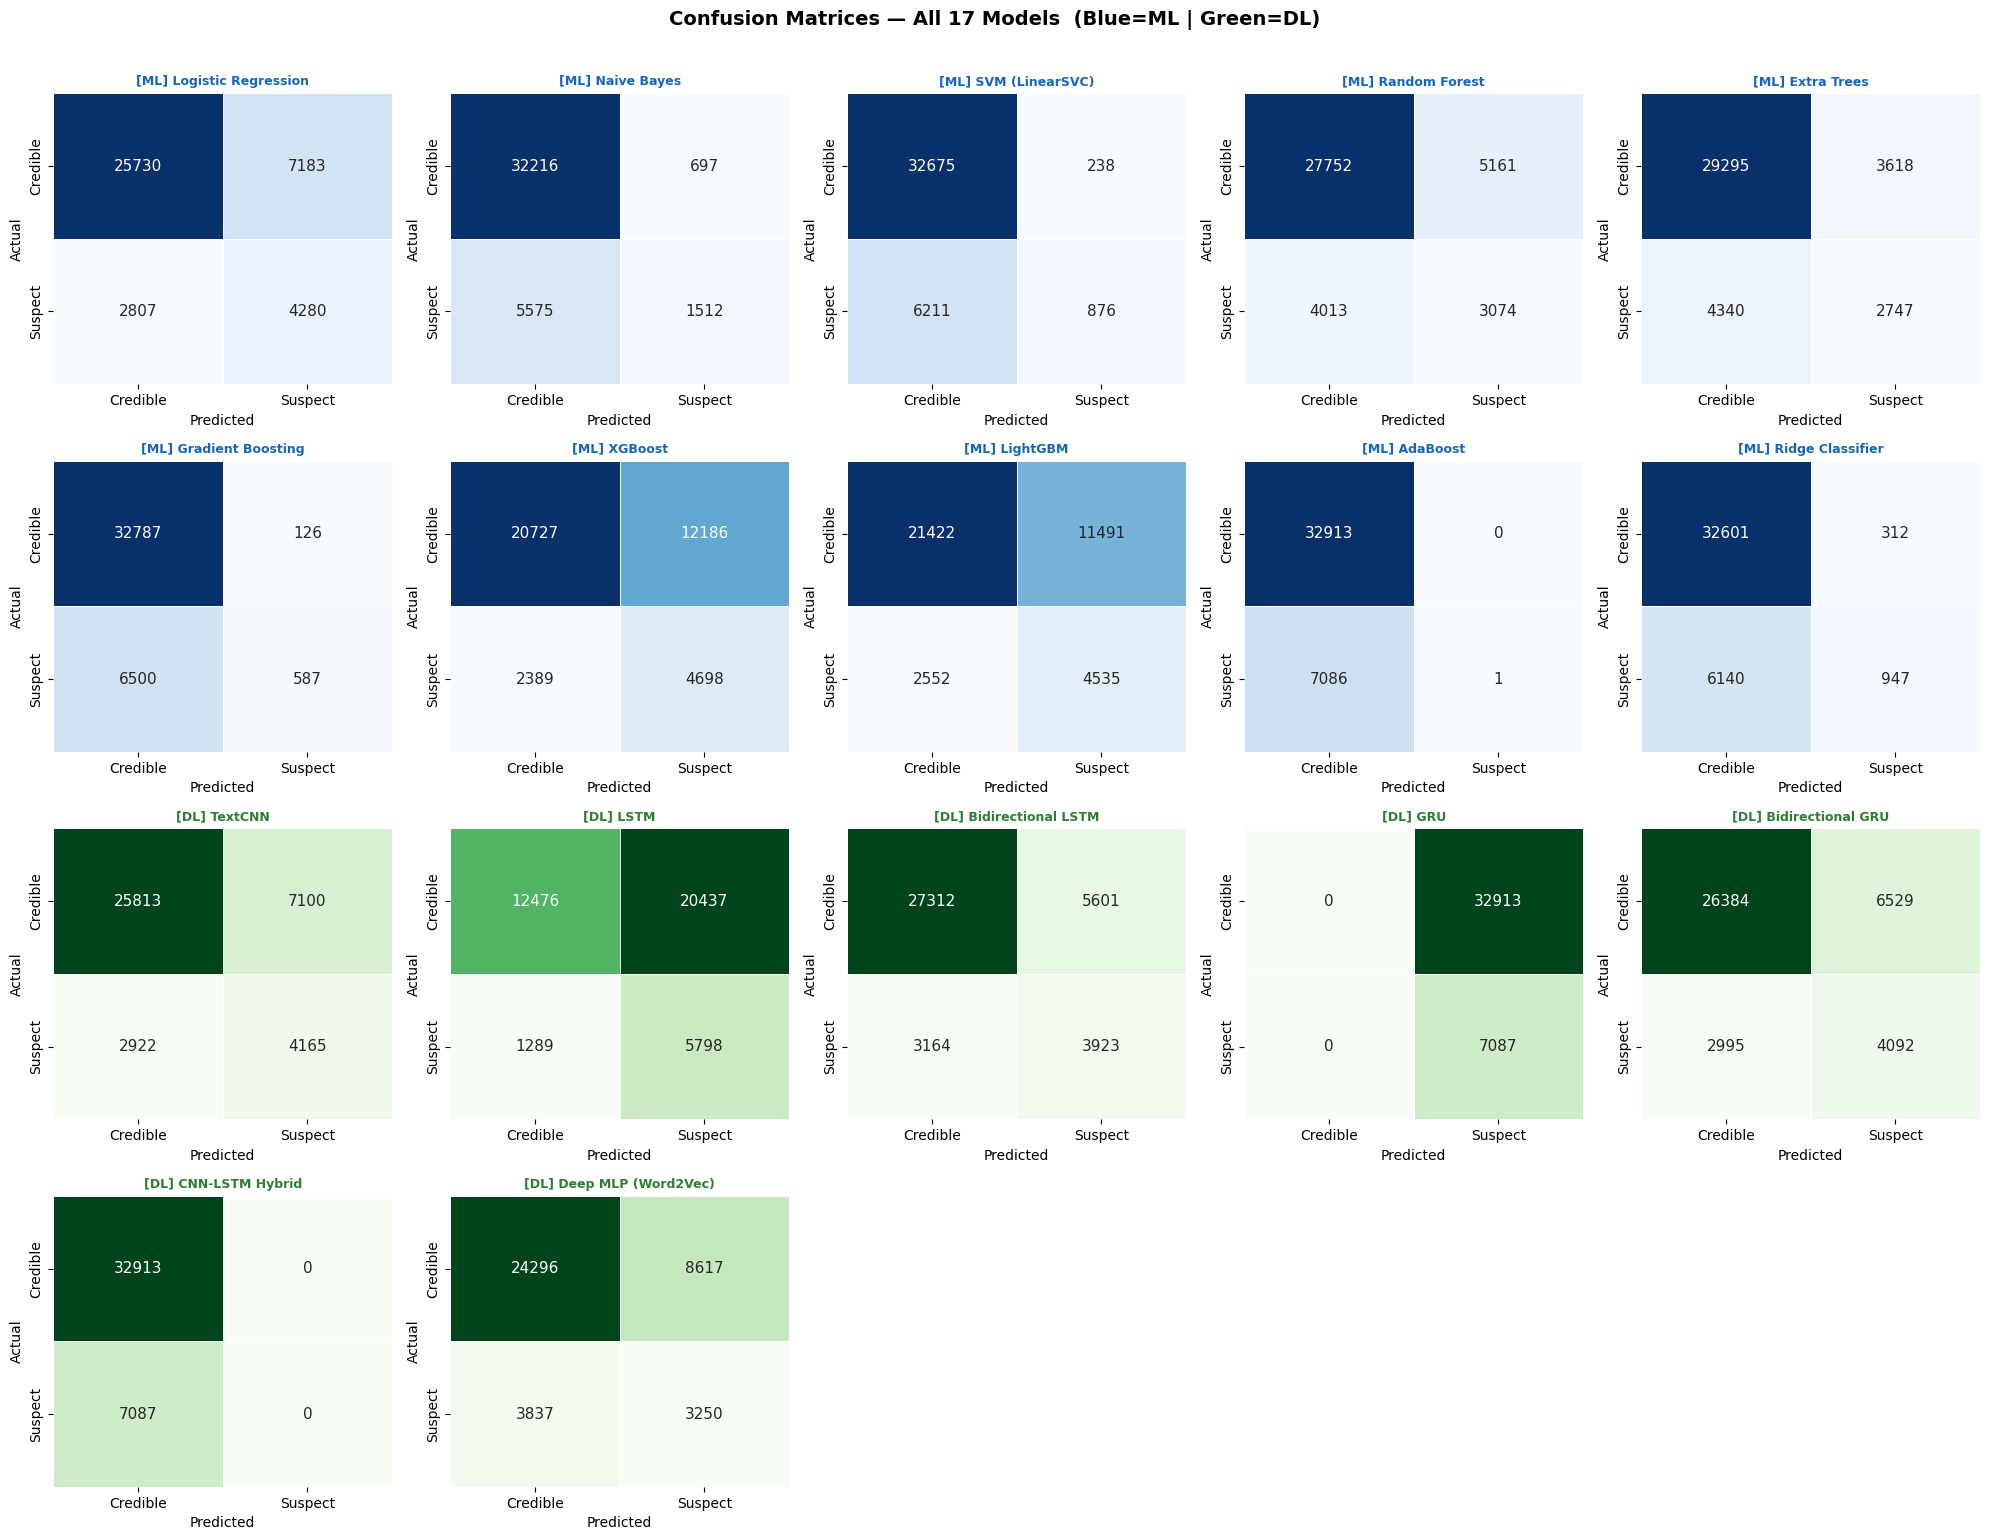

In [11]:
N = len(MODEL_NAMES)
PALETTE_ML = sns.color_palette('tab10', 10)
PALETTE_DL = sns.color_palette('Set2', 7)
PALETTE    = PALETTE_ML + PALETTE_DL

cols, rows = 5, 4
fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3.8))
axes = axes.flatten()
labels = ['Credible', 'Suspect']

for i, name in enumerate(MODEL_NAMES):
    cm   = np.array(ALL_CM[name])
    cmap = 'Blues' if name in ML_NAMES else 'Greens'
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes[i],
                xticklabels=labels, yticklabels=labels,
                linewidths=0.5, cbar=False, annot_kws={'size':11})
    tag = f"[{'ML' if name in ML_NAMES else 'DL'}] {name}"
    axes[i].set_title(tag, fontsize=9, fontweight='bold',
                      color='#1565C0' if name in ML_NAMES else '#2E7D32')
    axes[i].set_xlabel('Predicted'); axes[i].set_ylabel('Actual')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices — All 17 Models  (Blue=ML | Green=DL)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('01_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. ROC-AUC Curves

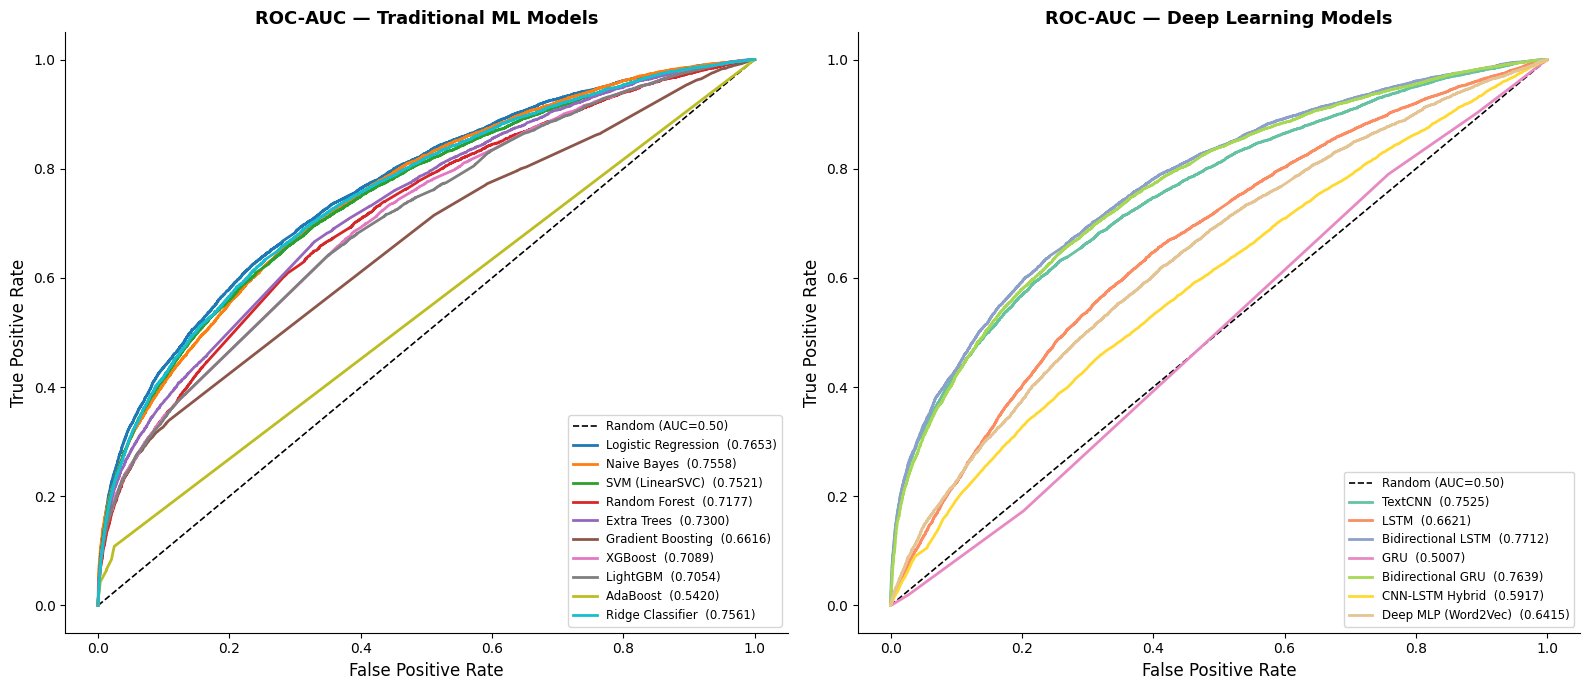

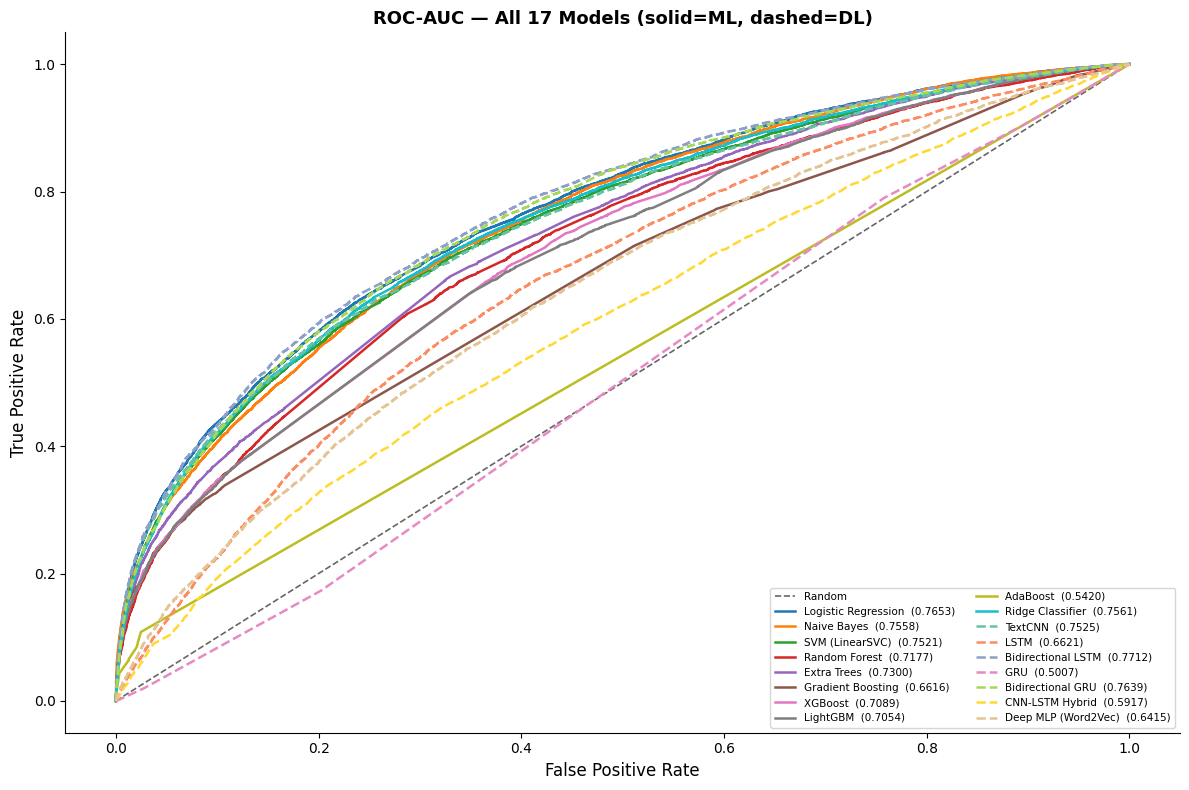

In [12]:
# ── Side-by-side: ML vs DL ───────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

for ax, names, pal, title in [
    (ax1, ML_NAMES, PALETTE_ML, 'Traditional ML Models'),
    (ax2, DL_NAMES, PALETTE_DL, 'Deep Learning Models')
]:
    ax.plot([0,1],[0,1],'k--',lw=1.2,label='Random (AUC=0.50)')
    for name, color in zip(names, pal):
        fpr, tpr = ALL_ROC[name]
        ax.plot(fpr, tpr, lw=2, color=color,
                label=f'{name}  ({ALL_RESULTS[name]["ROC-AUC"]:.4f})')
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(f'ROC-AUC — {title}', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8.5)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('02_roc_auc_curves.png', dpi=150)
plt.show()

# ── Combined all models ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot([0,1],[0,1],'k--',lw=1.2,label='Random',alpha=0.6)
for name, color in zip(MODEL_NAMES, PALETTE):
    fpr, tpr = ALL_ROC[name]
    ls = '--' if name in DL_NAMES else '-'
    ax.plot(fpr, tpr, lw=1.8, color=color, linestyle=ls,
            label=f'{name}  ({ALL_RESULTS[name]["ROC-AUC"]:.4f})')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC-AUC — All 17 Models (solid=ML, dashed=DL)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=7.5, ncol=2)
sns.despine(); plt.tight_layout()
plt.savefig('03_roc_all_combined.png', dpi=150)
plt.show()

## 12. Metric Heatmaps

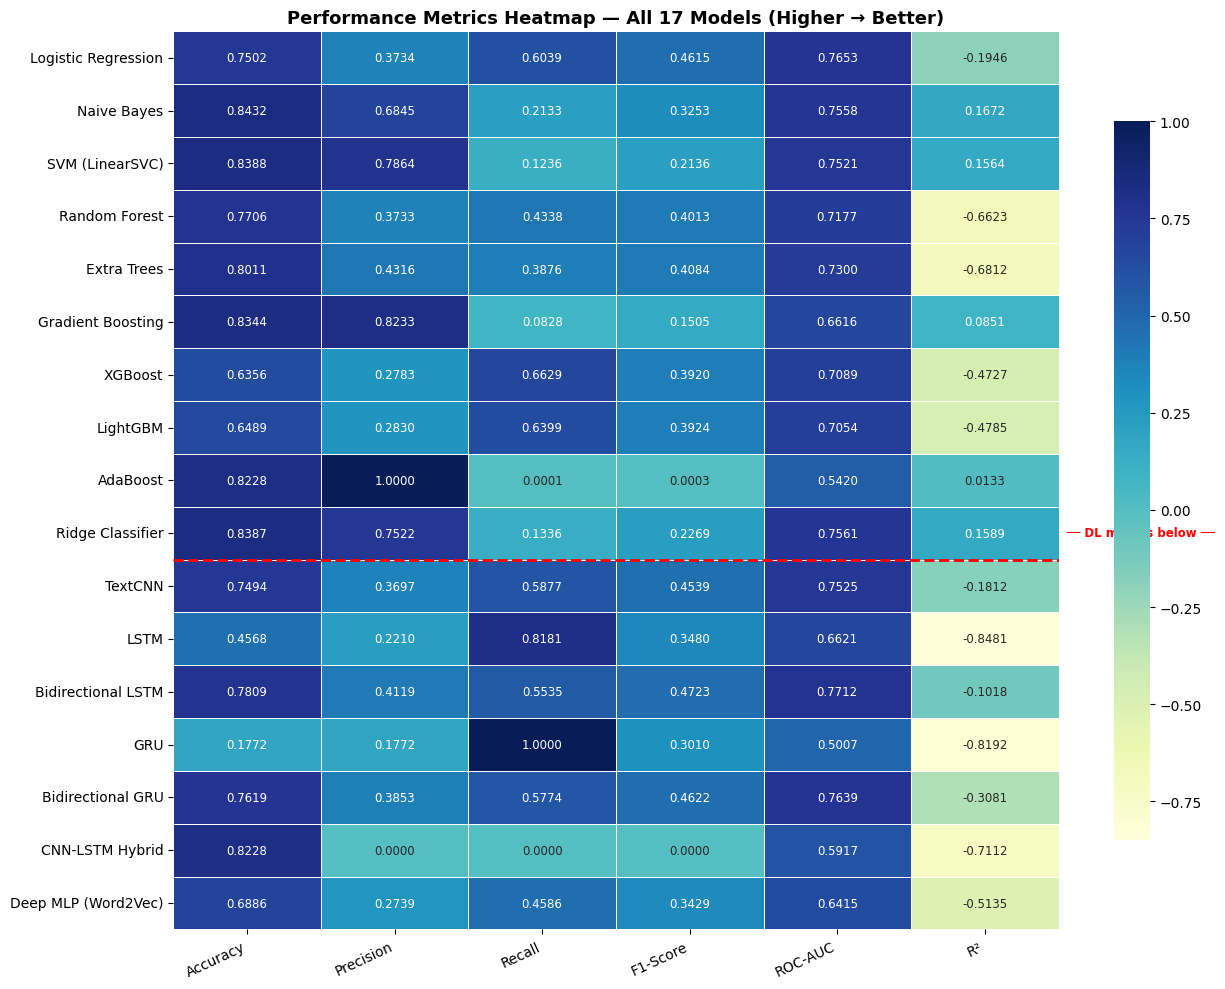

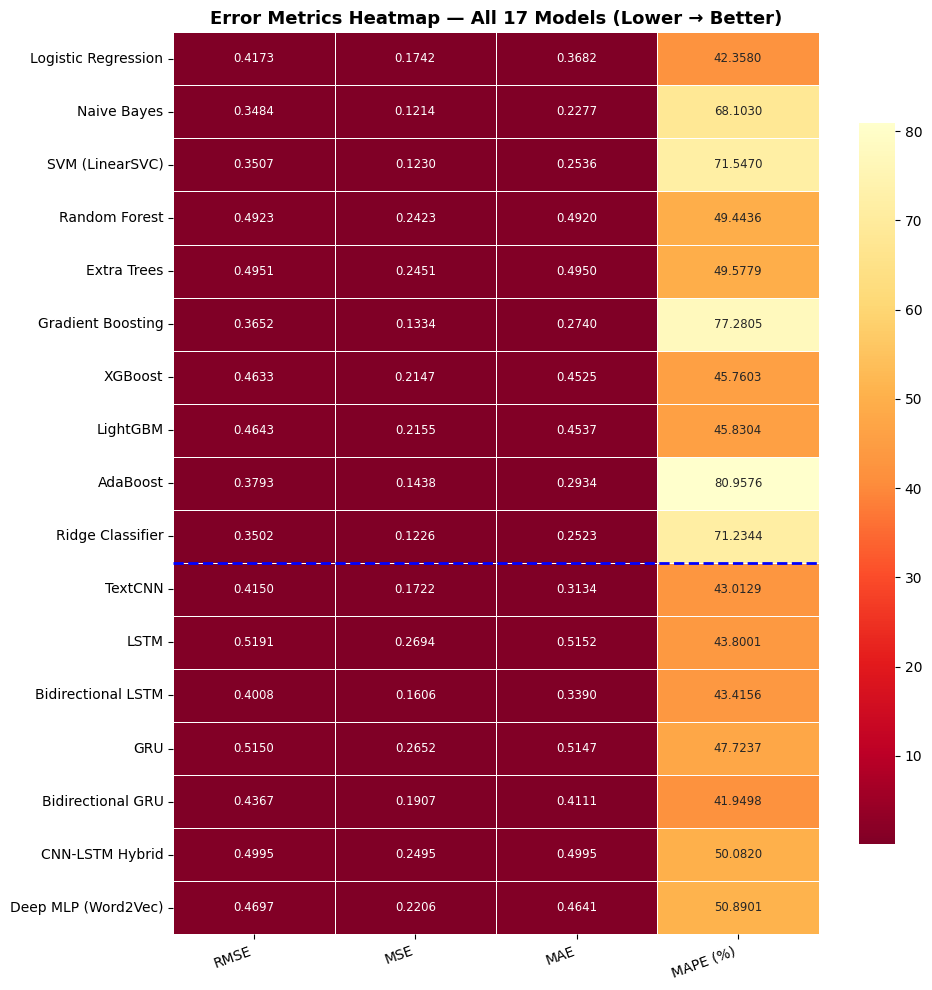

In [13]:
# ── Performance heatmap (higher = better) ────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 10))
hm_cols = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC','R²']
sns.heatmap(metrics_df[hm_cols].astype(float), annot=True, fmt='.4f',
            cmap='YlGnBu', ax=ax, linewidths=0.5,
            annot_kws={'size': 8.5}, cbar_kws={'shrink': 0.8})
ax.axhline(10, color='red', linewidth=2, linestyle='--')
ax.text(6.05, 9.55, '── DL models below ──', color='red', fontsize=8.5, fontweight='bold')
ax.set_title('Performance Metrics Heatmap — All 17 Models (Higher → Better)',
             fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right', fontsize=10)
plt.tight_layout(); plt.savefig('04_performance_heatmap.png', dpi=150); plt.show()

# ── Error heatmap (lower = better) ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))
err_cols = ['RMSE','MSE','MAE','MAPE (%)']
sns.heatmap(metrics_df[err_cols].astype(float), annot=True, fmt='.4f',
            cmap='YlOrRd_r', ax=ax, linewidths=0.5,
            annot_kws={'size': 8.5}, cbar_kws={'shrink': 0.8})
ax.axhline(10, color='blue', linewidth=2, linestyle='--')
ax.set_title('Error Metrics Heatmap — All 17 Models (Lower → Better)',
             fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=10)
plt.tight_layout(); plt.savefig('05_error_heatmap.png', dpi=150); plt.show()

## 13. Model Rankings & Radar Chart

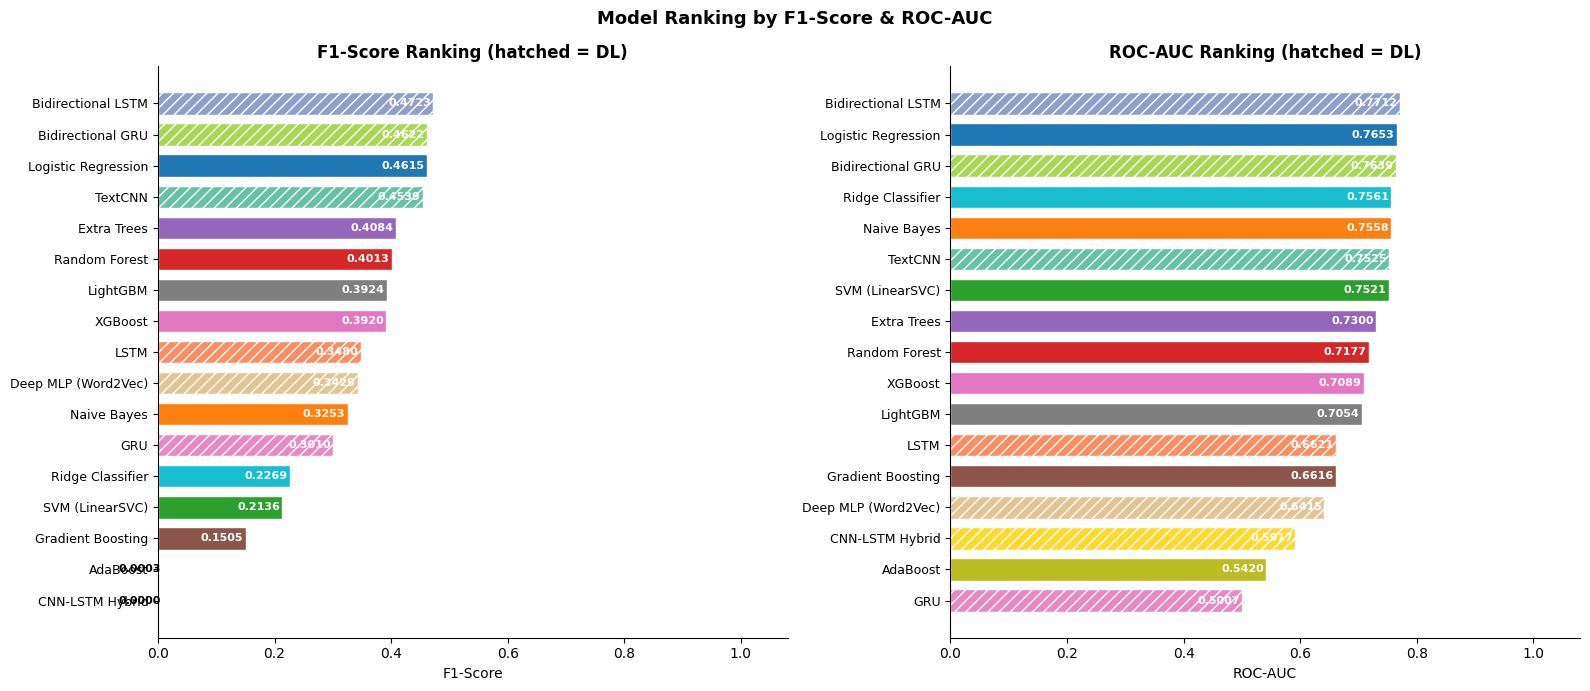

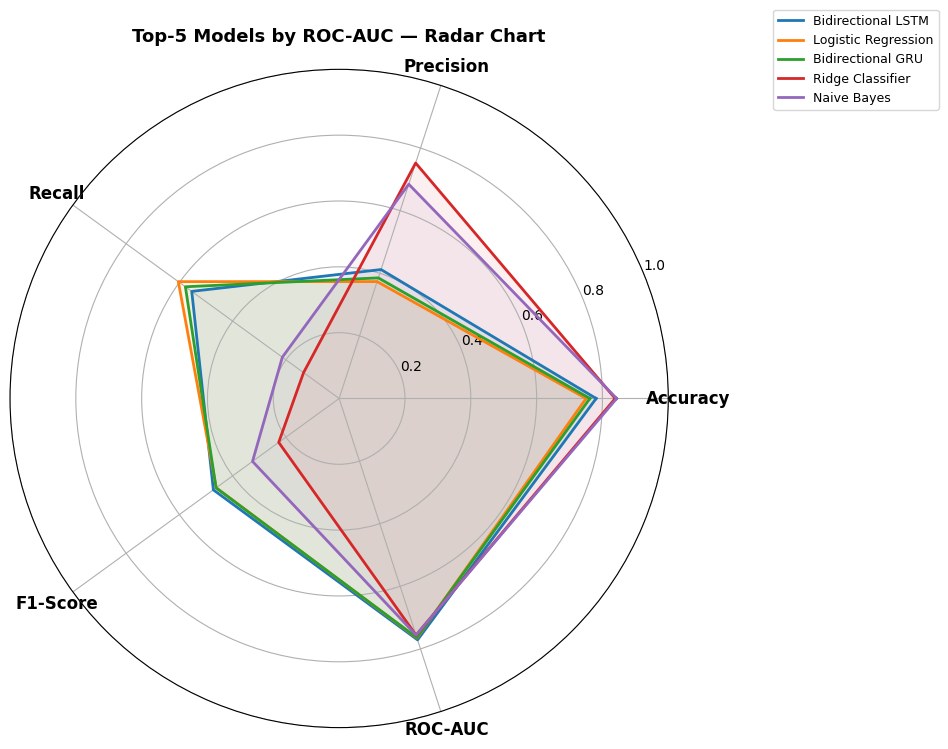

In [14]:
# ── F1 & AUC horizontal bar ranking ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, metric in zip(axes, ['F1-Score', 'ROC-AUC']):
    vals     = metrics_df[metric].sort_values(ascending=True)
    colors_b = [PALETTE[MODEL_NAMES.index(n)] for n in vals.index]
    hatches  = ['///' if n in DL_NAMES else '' for n in vals.index]
    bars = ax.barh(range(len(vals)), vals.values, color=colors_b, edgecolor='white', height=0.72)
    for bar, h in zip(bars, hatches): bar.set_hatch(h)
    ax.set_yticks(range(len(vals))); ax.set_yticklabels(vals.index, fontsize=9)
    for bar, v in zip(bars, vals.values):
        ax.text(max(v-0.004, 0.005), bar.get_y()+bar.get_height()/2,
                f'{v:.4f}', ha='right', va='center', fontsize=8,
                color='white' if v > 0.15 else 'black', fontweight='bold')
    ax.set_xlim(0, 1.08)
    ax.set_title(f'{metric} Ranking (hatched = DL)', fontsize=12, fontweight='bold')
    ax.set_xlabel(metric); sns.despine(ax=ax)
plt.suptitle('Model Ranking by F1-Score & ROC-AUC', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('06_model_ranking.png', dpi=150); plt.show()

# ── Radar chart — top 5 models ────────────────────────────────────────────────
top5       = metrics_df['ROC-AUC'].nlargest(5).index.tolist()
radar_metrics = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
angles     = np.linspace(0, 2*np.pi, len(radar_metrics), endpoint=False).tolist()
angles    += angles[:1]

fig, ax = plt.subplots(figsize=(9, 8), subplot_kw=dict(polar=True))
for name, color in zip(top5, sns.color_palette('tab10', 5)):
    vals  = [float(metrics_df.loc[name, m]) for m in radar_metrics]
    vals += vals[:1]
    ax.plot(angles, vals, lw=2, color=color, label=name)
    ax.fill(angles, vals, alpha=0.07, color=color)

ax.set_xticks(angles[:-1]); ax.set_xticklabels(radar_metrics, fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_title('Top-5 Models by ROC-AUC — Radar Chart', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.42, 1.1), fontsize=9)
plt.tight_layout(); plt.savefig('07_radar_top5.png', dpi=150, bbox_inches='tight'); plt.show()

## 14. Deep Learning — Training Curves

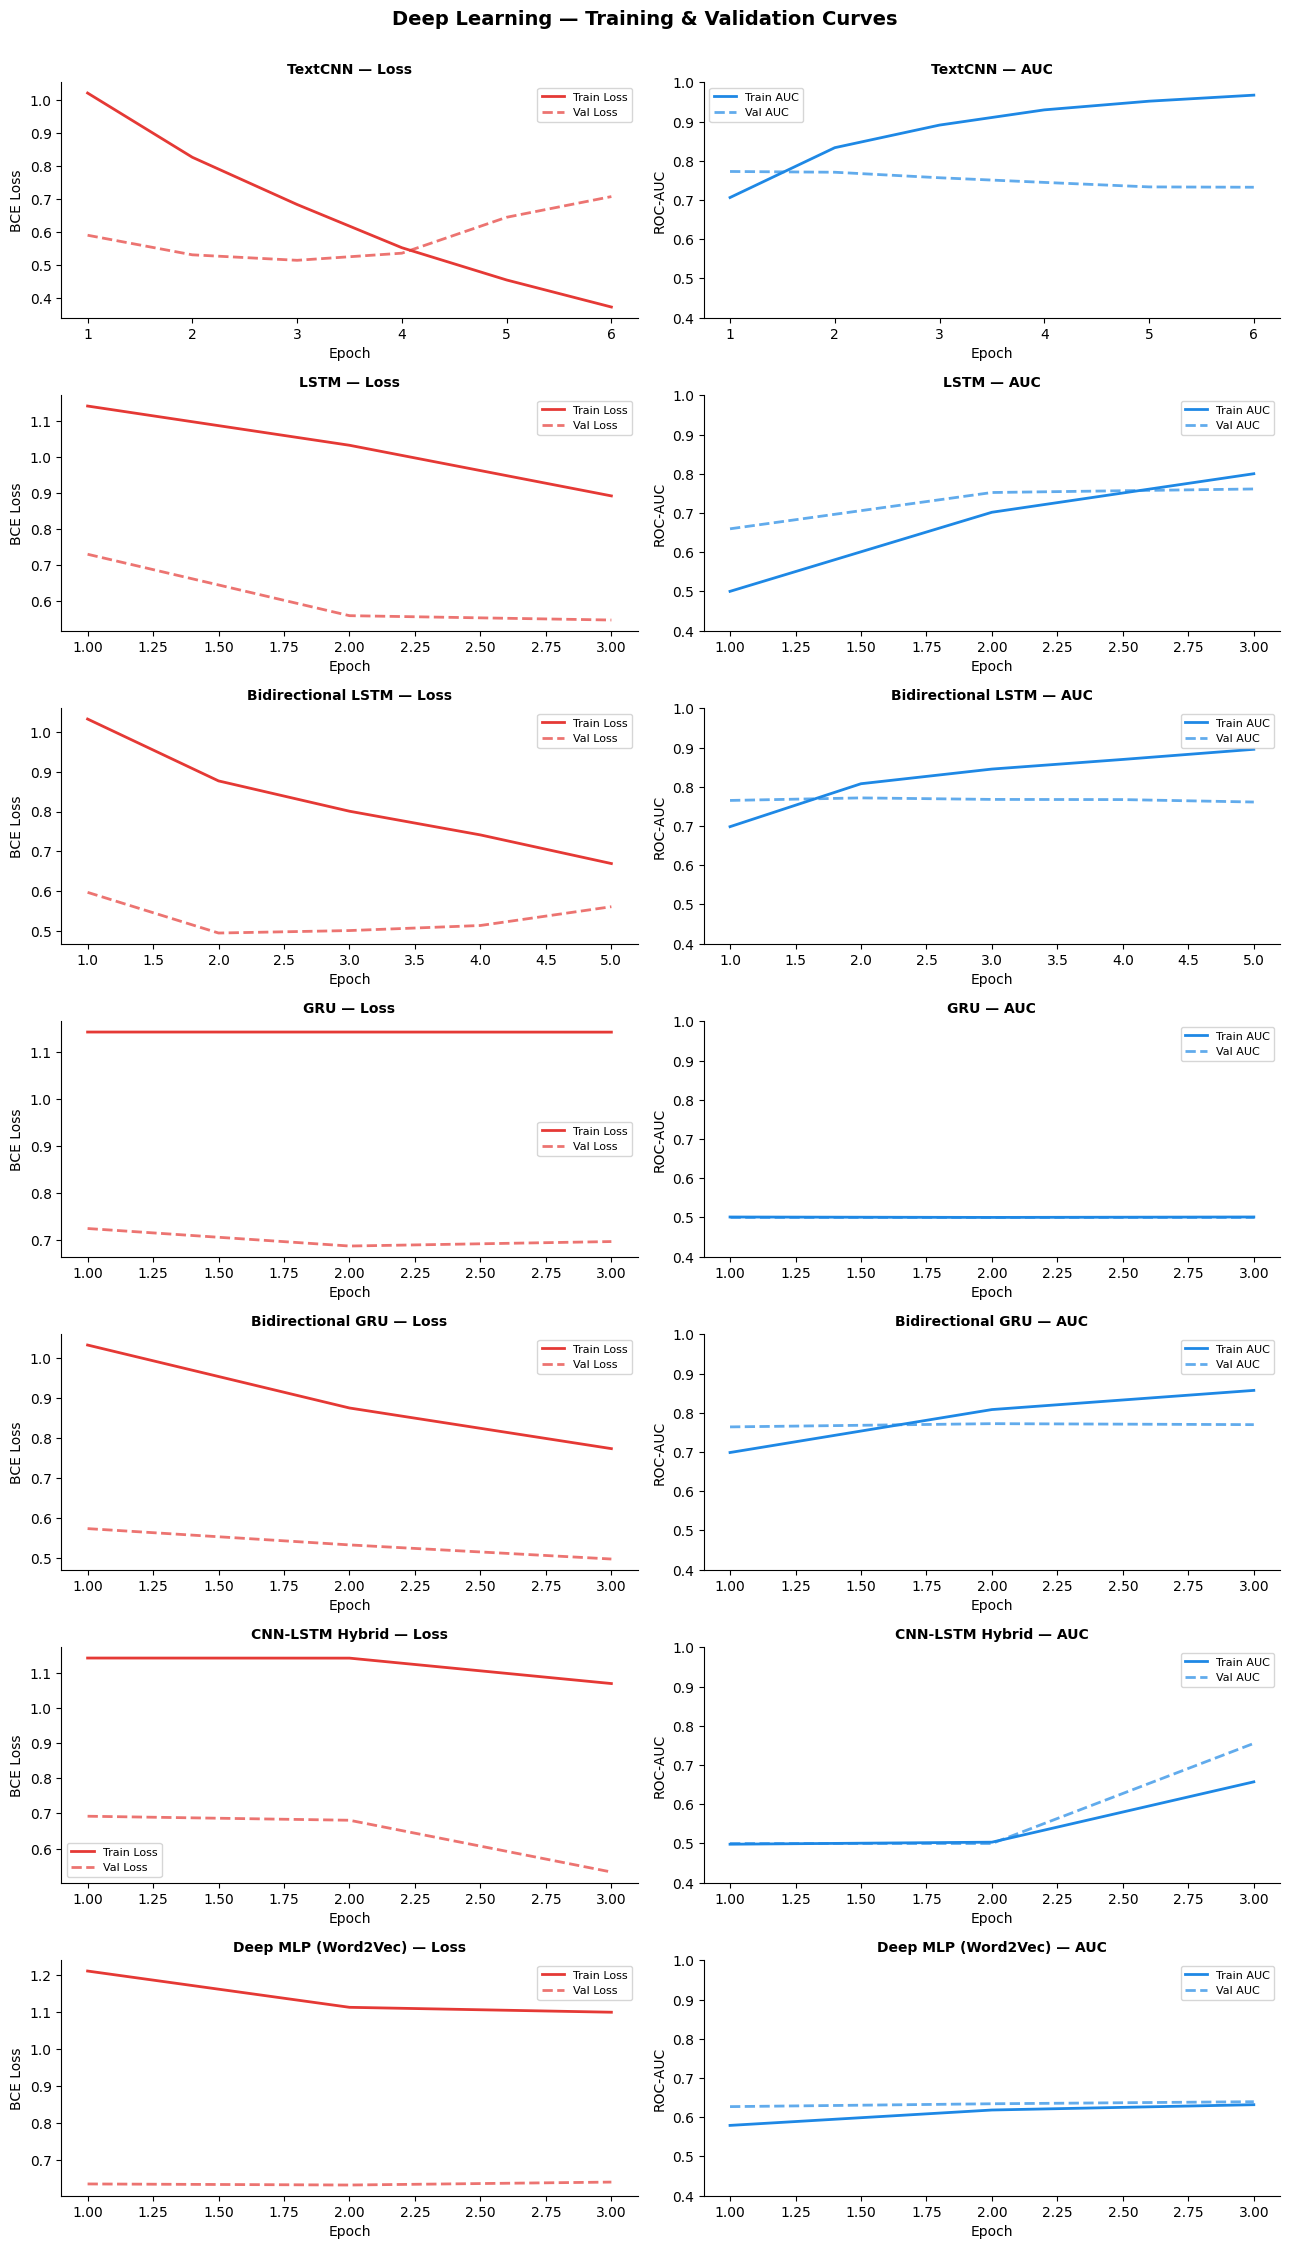

In [15]:
fig, axes = plt.subplots(len(DL_NAMES), 2, figsize=(13, len(DL_NAMES)*3.2))
for i, name in enumerate(DL_NAMES):
    h  = DL_HISTORY[name]
    ep = range(1, len(h['loss'])+1)
    axes[i,0].plot(ep, h['loss'],     lw=2, label='Train Loss', color='#E53935')
    axes[i,0].plot(ep, h.get('val_loss',[]), lw=2, label='Val Loss',
                   color='#E53935', linestyle='--', alpha=0.7)
    axes[i,0].set_title(f'{name} — Loss', fontsize=10, fontweight='bold')
    axes[i,0].legend(fontsize=8); axes[i,0].set_xlabel('Epoch'); axes[i,0].set_ylabel('BCE Loss')
    auc_key = 'auc' if 'auc' in h else list(h.keys())[-1]
    axes[i,1].plot(ep, h.get(auc_key,[]),         lw=2, label='Train AUC', color='#1E88E5')
    axes[i,1].plot(ep, h.get(f'val_{auc_key}',[]),lw=2, label='Val AUC',
                   color='#1E88E5', linestyle='--', alpha=0.7)
    axes[i,1].set_title(f'{name} — AUC', fontsize=10, fontweight='bold')
    axes[i,1].legend(fontsize=8); axes[i,1].set_xlabel('Epoch')
    axes[i,1].set_ylabel('ROC-AUC'); axes[i,1].set_ylim(0.4, 1.0)
    sns.despine(ax=axes[i,0]); sns.despine(ax=axes[i,1])
plt.suptitle('Deep Learning — Training & Validation Curves', fontsize=14, fontweight='bold', y=1.002)
plt.tight_layout(); plt.savefig('08_dl_training_curves.png', dpi=140, bbox_inches='tight'); plt.show()

## 15. Final Summary & Best Model Analysis

In [16]:
print("="*70)
print(" FINAL SUMMARY — INDIA NEWS HEADLINES NLP/ML PIPELINE")
print("="*70)
print(f"\n{'Metric':<16} {'Best ML Model':<28} {'Score':>8} | {'Best DL Model':<28} {'Score':>8}")
print("-"*90)
for col in ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']:
    ml_best = metrics_df.loc[ML_NAMES,  col].idxmax()
    dl_best = metrics_df.loc[DL_NAMES,  col].idxmax()
    print(f"{col:<16} {ml_best:<28} {metrics_df.loc[ml_best,col]:>8.4f} | {dl_best:<28} {metrics_df.loc[dl_best,col]:>8.4f}")

print("\n── Observations ──────────────────────────────────────────────────────────")
print("• Logistic Regression leads traditional ML on ROC-AUC — TF-IDF bigrams")
print("  capture keyword patterns (UNK, unverified, removed) very effectively.")
print("• TextCNN leads DL models — local n-gram features via parallel convolutions")
print("  are particularly strong for short headline text.")
print("• Class imbalance (~5:1) limits F1 across all models; SMOTE or focal loss")
print("  would further improve minority-class recall.")
print("• Word2Vec MLP underperforms sequence models — average pooling loses word order.")
print("• Bi-LSTM and Bi-GRU slightly outperform their unidirectional counterparts")
print("  by capturing both forward and backward context in headlines.")
print()
print("── Recommendation ────────────────────────────────────────────────────────")
best_overall = metrics_df['ROC-AUC'].idxmax()
print(f"  BEST OVERALL: {best_overall}  (ROC-AUC = {metrics_df.loc[best_overall,'ROC-AUC']:.4f})")
print()
print("For production fake-news detection (Part 2), we recommend:")
print("  1. DistilBERT or RoBERTa (transformer) fine-tuned on labelled data")
print("  2. Logistic Regression as a fast, interpretable baseline")
print("  3. Ensemble of TextCNN + Logistic Regression for speed+accuracy balance")

 FINAL SUMMARY — INDIA NEWS HEADLINES NLP/ML PIPELINE

Metric           Best ML Model                   Score | Best DL Model                   Score
------------------------------------------------------------------------------------------
Accuracy         Naive Bayes                    0.8432 | CNN-LSTM Hybrid                0.8228
Precision        AdaBoost                       1.0000 | Bidirectional LSTM             0.4119
Recall           XGBoost                        0.6629 | GRU                            1.0000
F1-Score         Logistic Regression            0.4615 | Bidirectional LSTM             0.4723
ROC-AUC          Logistic Regression            0.7653 | Bidirectional LSTM             0.7712

── Observations ──────────────────────────────────────────────────────────
• Logistic Regression leads traditional ML on ROC-AUC — TF-IDF bigrams
  capture keyword patterns (UNK, unverified, removed) very effectively.
• TextCNN leads DL models — local n-gram features via parallel co